In [1]:
# Setup: imports and global configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Use a consistent style for plots
# plt.style.use('seaborn-v0_8')

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Utilities: helper functions for analysis
from typing import Optional, Tuple

# Reuse helpers from src.utils
from src.utils.analysis import predict_all, tsne_scatter
import src.utils.analysis as analysis
import src.utils.interpretability as interp


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/reg_mixer_attnpl_t_20260204-161105") 
# checkpoints/reg_mixer_attnpl_t_20260131-114145
checkpoint_path = checkpoint_dir / "last_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Tanh()
          (1): Linear(in_features=1, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (f

In [4]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/regressor/regressor_Mc_3_Mf_3_Tfore_180_Twindow_360_context_le

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [6]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

In [7]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)

In [8]:
model.base_model.input_adapter.mag_mean_gr

tensor(3.5069)

In [9]:
# model.base_model.input_adapter(x)['features'][0,:,0]
# odel.base_model.encoder.input_proj(model.base_model.input_adapter(x)['features'])[0,0,:]

In [10]:
mag = torch.linspace(3, 7.5, steps=x.shape[1], device=x.device).unsqueeze(0).expand(x.shape[0], -1)
x[:,:,2] = mag

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


mean: 0.0006607489776797593
std : 0.0430402047932148
min : -0.1209554523229599
max : 0.12184396386146545


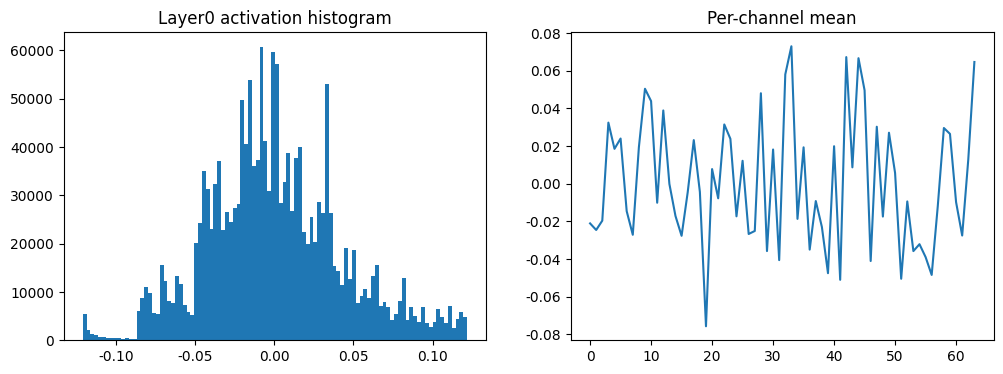

In [11]:
import matplotlib.pyplot as plt
# Capture activations after encoder layer[0]
layer0_out = []

def _hook(module, inp, out):
    # out may be tuple: (hidden_states, residual)
    if isinstance(out, tuple):
        out = out[0]

    layer0_out.append(out.detach().cpu())

# hook_handle = model.base_model.encoder.layers[0].register_forward_hook(_hook)
hook_handle = model.base_model.encoder.input_proj.register_forward_hook(_hook)

with torch.no_grad():
    _ = model(x)

hook_handle.remove()

# ===== visualize =====
if len(layer0_out) > 0:
    h = layer0_out[0]   # (B, L, D)

    # Global stats
    print("mean:", h.mean().item())
    print("std :", h.std().item())
    print("min :", h.min().item())
    print("max :", h.max().item())

    # Per-channel mean
    channel_means = h.mean(dim=(0, 1)).numpy()

    # Flatten histogram
    h_flat = h.reshape(-1).numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(h_flat, bins=100)
    plt.title("Layer0 activation histogram")

    plt.subplot(1,2,2)
    plt.plot(channel_means)
    plt.title("Per-channel mean")

    plt.show()
else:
    print("No activations captured.")

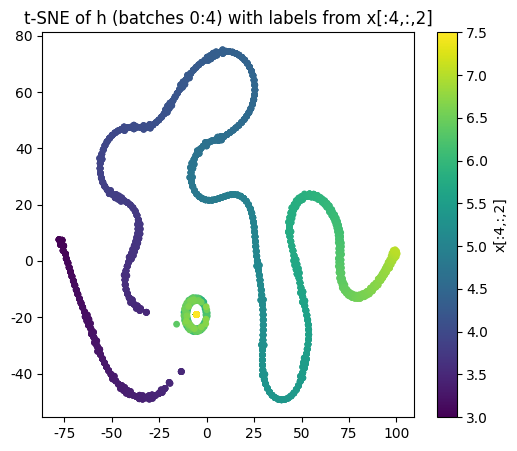

In [12]:
# t-SNE on pooled inputs with labels from batches 0:4
h_np = interp.to_numpy(h[:5]).reshape(-1, h.shape[-1])   # (4*L, D)
labels = interp.to_numpy(x[:5, :, 2]).reshape(-1)        # (4*L,)

X_emb = TSNE(n_components=2, random_state=42).fit_transform(h_np)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap="viridis", s=15)
plt.colorbar(sc, label="x[:4,:,2]")
plt.title("t-SNE of h (batches 0:4) with labels from x[:4,:,2]")
plt.show()

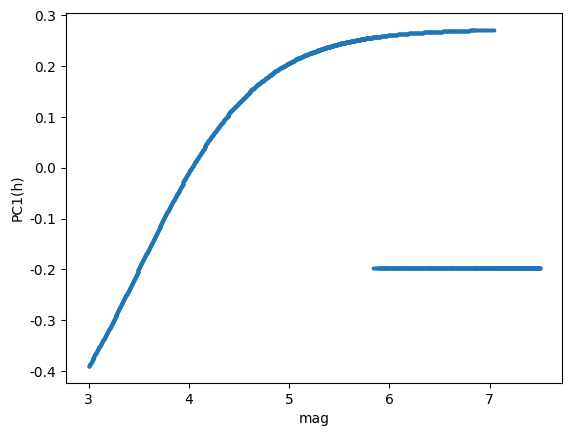

In [13]:
from sklearn.decomposition import PCA
pc1 = PCA(n_components=1).fit_transform(h_np)[:,0]
plt.scatter(labels, pc1, s=3)
plt.xlabel("mag")
plt.ylabel("PC1(h)")
plt.show()


In [14]:
from src.utils.metrics import regression_metrics, log_metrics, plot_and_save_roc_curve
y_pred_val, y_val, X_val = analysis.predict_all(model,val_loader, device, return_X=True)

start=0
end =400
regression_metrics(y_val[start:end], y_pred_val[start:end])  

{'RMSE': 0.15683927190979488,
 'MAE': 0.1286159776724302,
 'MSE': 0.024598557213194573,
 'MAPE': 29.121228579154735,
 'R2': -0.4813664174901493,
 'PearsonR': -0.055841533441214654,
 'PearsonR_diff': 0.07966911688891834,
 'DA': 0.049723756906077346,
 'SpearmanR': -0.07009264575487215,
 'SpearmanR_diff': 0.07375709622177248,
 'DTW': 17.522250771522522,
 'DTW_normalized': 0.09627610314023363}

In [15]:
X_all = X_val
y_all = y_val
y_pred_all = y_pred_val

/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


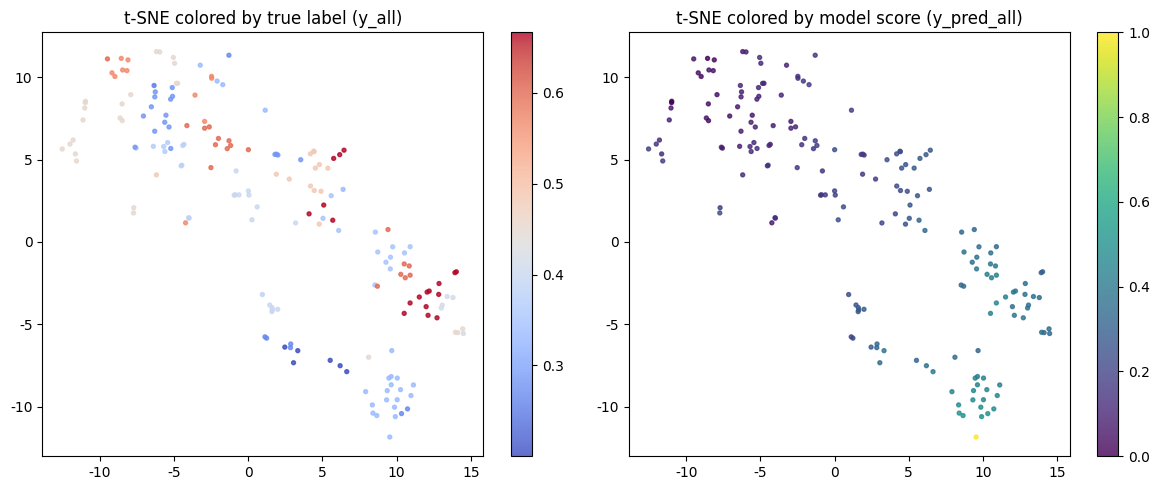

In [16]:
# t-SNE visualization of pooled features
X_scaled, X_tsne, y_score = analysis.tsne_scatter(X_all, y_all, y_pred_all)

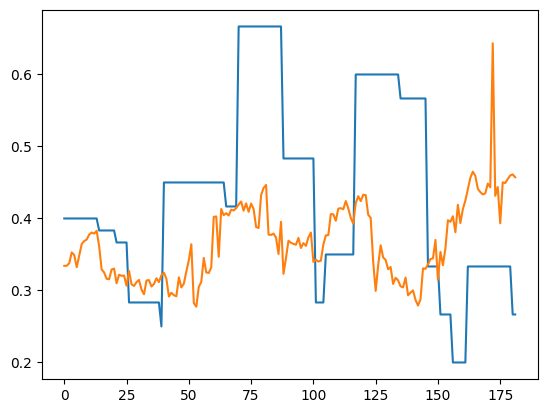

In [17]:
plt.plot(y_all,)
plt.plot(y_pred_all)

In [18]:
xs, ys = [], []
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    xs.append(x) 
    ys.append(y)

In [19]:
import importlib
importlib.reload(interp)

<module 'src.utils.interpretability' from '/root/autodl-tmp/chuandian_eq/src/utils/interpretability.py'>

In [20]:
# Token Importance: unified compute function
scores, label = interp.compute_token_importance(model, x, method='ig', n_steps=40)

In [34]:
sample_idx =12

In [35]:
from src.utils.mask_utils import get_non_pad_mask
mask = get_non_pad_mask(x[:,:,0]).squeeze(-1)

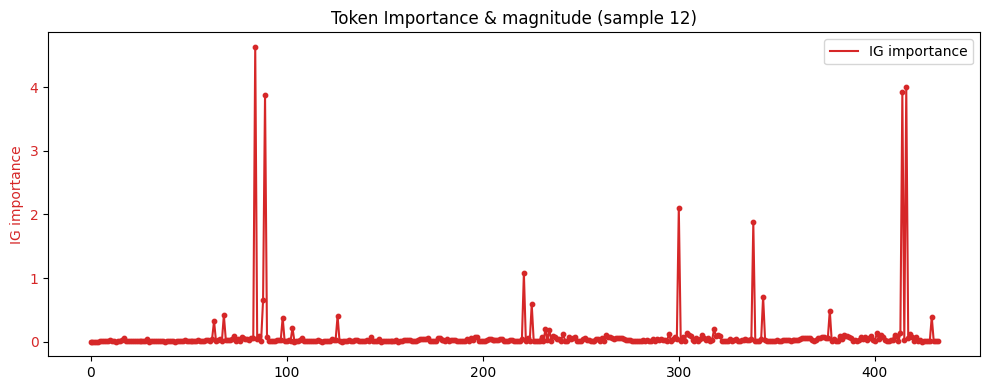

In [36]:
interp.plot_token_importance(scores, sample_idx=sample_idx,mask=mask, label=label, color='tab:red')

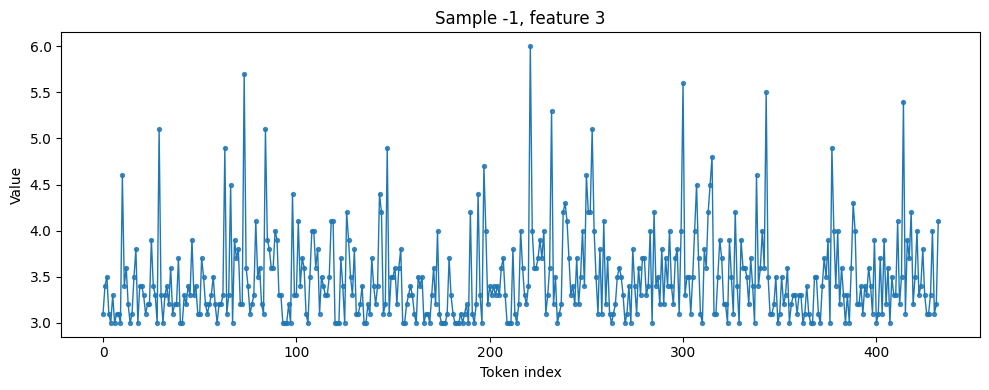

In [37]:
interp.plot_sequence(
    x,
    sample_idx=sample_idx,
    feature_idx=2,
    mask=mask,
    title="Sample -1, feature 3",
)

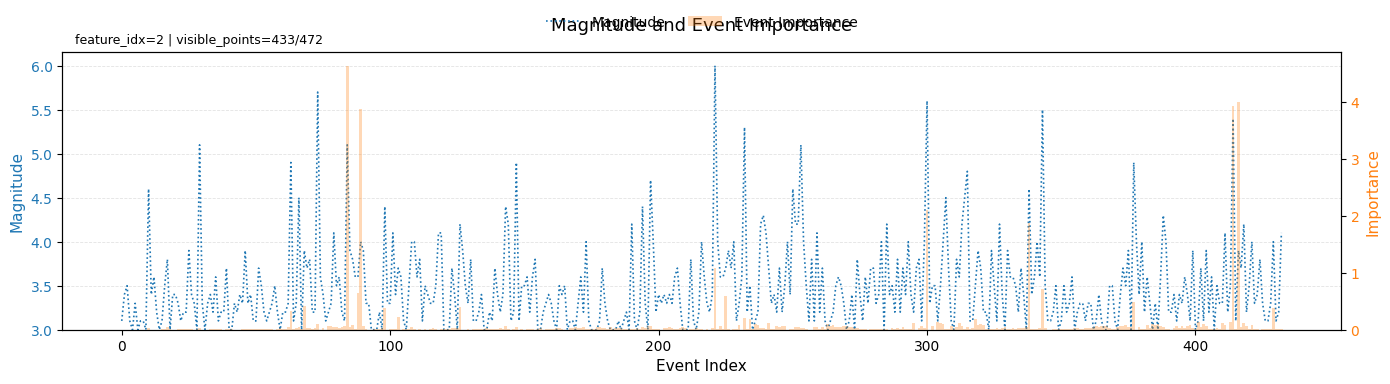

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Configuration
# -----------------------------
feature_idx = 2          # feature dimension to visualize
min_magnitude = 3.0      # lower bound for magnitude y-axis

# -----------------------------
# Data extraction
# -----------------------------
seq = interp.to_numpy(x[sample_idx, :, feature_idx])     # (L,)
importance = interp.to_numpy(scores[sample_idx])         # (L,)
length = seq.shape[0]
x_axis = np.arange(length)

# -----------------------------
# Mask handling
# -----------------------------
def get_sample_mask(mask_obj, sample_idx, length):
    """Return boolean mask of shape (L,). If mask_obj is None -> all True."""
    if mask_obj is None:
        return np.ones(length, dtype=bool)

    sample_mask = mask_obj[sample_idx]
    if getattr(sample_mask, "ndim", 1) > 1:
        sample_mask = sample_mask.squeeze()

    sample_mask = interp.to_numpy(sample_mask).astype(bool)

    if sample_mask.shape[0] != length:
        raise ValueError("Mask length does not match sequence length")

    return sample_mask


try:
    sample_mask = get_sample_mask(mask, sample_idx, length)
except NameError:
    sample_mask = np.ones(length, dtype=bool)

# -----------------------------
# Apply mask
# -----------------------------
valid_idx = np.flatnonzero(sample_mask)
if valid_idx.size == 0:
    print("No visible points under current mask; skipping plot.")
else:
    x_valid = x_axis[valid_idx]
    seq_valid = seq[valid_idx]
    importance_valid = importance[valid_idx]

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax_mag = plt.subplots(figsize=(14, 4))

    # Magnitude (dotted line)
    line_mag, = ax_mag.plot(
        x_valid,
        seq_valid,
        linestyle=':',      # 点状线
        linewidth=1.2,
        color='C0',
        label='Magnitude'
    )
    ax_mag.set_xlabel('Event Index', fontsize=11)
    ax_mag.set_ylabel('Magnitude', fontsize=11, color='C0')
    ax_mag.tick_params(axis='y', labelcolor='C0')
    ax_mag.set_ylim(bottom=min_magnitude)

    # Grid: only on magnitude axis for readability
    ax_mag.grid(
        axis='y',
        linestyle='--',
        linewidth=0.6,
        alpha=0.35
    )

    # Importance bars (secondary axis)
    ax_imp = ax_mag.twinx()
    bars = ax_imp.bar(
        x_valid,
        importance_valid,
        width=1.0,
        color='C1',
        alpha=0.30,
        label='Event Importance'
    )
    ax_imp.set_ylabel('Importance', fontsize=11, color='C1')
    ax_imp.tick_params(axis='y', labelcolor='C1')
    ax_imp.set_ylim(bottom=0.0)

    # Title
    ax_mag.set_title('Magnitude and Event Importance', fontsize=13, pad=16)

    # Legend: combine handles from both axes, place above, avoid covering data
    ax_mag.legend(
        handles=[line_mag, bars],
        labels=['Magnitude', 'Event Importance'],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.18),
        ncol=2,
        frameon=False,
        fontsize=10,
        handlelength=2.5,
        columnspacing=1.6
    )


    plt.tight_layout()
    plt.show()


In [39]:
# Example: run numeric token ranking + deletion validation on `x` and `scores`
# Assumptions:
# - `x`: tensor [B, L, D] is defined earlier (e.g., batch from test_loader)
# - `scores`: tensor [B, L] computed via `compute_token_importance(model, x, ...)`
# - `sample_idx`: integer index of sample to analyze

import torch

# Validate prerequisites
try:
    _ = x
    _ = scores
    _ = sample_idx
except NameError:
    raise RuntimeError("Please define `x`, `scores`, and `sample_idx` earlier.")

# Build a valid token mask (True = token has non-zero features)
valid_mask = (x[sample_idx].abs().sum(dim=-1) > 0)

# Rank tokens
ranks = interp.rank_tokens_numeric(token_scores=scores, sample_idx=sample_idx, valid_mask=valid_mask, topn=20)
print("Top tokens by importance (index, score):")
for i, (idx, sc) in enumerate(ranks['top'], 1):
    print(f"{i:>2}. idx={idx:<3} score={sc:.6f}")

# Deletion validation with zeroing tokens
validation = interp.deletion_validation_numeric(
    model=model,
    x=x,
    token_scores=scores,
    sample_idx=sample_idx,
    topk_list=(1, 2, 5, 10),
    deletion_mode='zero',            # alternatives: 'baseline', 'noise'
    baseline_strategy='zeros',       # used only when deletion_mode='baseline'
    valid_mask=valid_mask,
    return_details=True,
)

print(f"Baseline prediction: {validation['baseline']:.6f}")
print("Top-k deletion drops:")
for r in validation['results']['topk']:
    print(f"k={r['k']:>2} drop={r['drop']:.6f}")

print("Least-k deletion drops (sanity):")
for r in validation['results']['leastk']:
    print(f"k={r['k']:>2} drop={r['drop']:.6f}")


Top tokens by importance (index, score):
 1. idx=84  score=4.633312
 2. idx=416 score=4.000655
 3. idx=414 score=3.922338
 4. idx=89  score=3.878880
 5. idx=300 score=2.108935
 6. idx=338 score=1.875775
 7. idx=221 score=1.078868
 8. idx=343 score=0.708406
 9. idx=88  score=0.652831
10. idx=225 score=0.585305
11. idx=377 score=0.487345
12. idx=68  score=0.416081
13. idx=126 score=0.402306
14. idx=429 score=0.388797
15. idx=98  score=0.377089
16. idx=63  score=0.322142
17. idx=103 score=0.216668
18. idx=232 score=0.199998
19. idx=318 score=0.195101
20. idx=234 score=0.187313
Baseline prediction: 0.391137
Top-k deletion drops:
k= 1 drop=0.008370
k= 2 drop=0.003757
k= 5 drop=-0.007530
k=10 drop=-0.005420
Least-k deletion drops (sanity):
k= 1 drop=0.000000
k= 2 drop=0.000000
k= 5 drop=0.000000
k=10 drop=0.000000
